# Project — Euro Area Risk-Free Rates: Vasicek Model

## 1 - Context

Reconstructing the yield curve is important in both finance and insurance, especially for computing present values.  
In this project, the goal is to reconstruct a short-term risk-free rate curve for the euro area, over horizons from 2 to 5 years, using a stochastic model calibrated on real market data.

For accessibility reasons, we use publicly available data:

- EURIBOR rates as proxies for short-term euro area market rates;
- EIOPA long-term assumptions to set the long-run equilibrium level.

The model used throughout the notebook is the Vasicek short-rate model. It is simple, analytically tractable, and useful for understanding mean reversion in interest rates.


In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

rng_global = np.random.default_rng(42)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Libraries loaded ✓")


Libraries loaded ✓


### Vasicek Model (1977)

The instantaneous risk-free rate $R_t$ follows the Vasicek stochastic differential equation:

$$
dR_t = \alpha(\beta - R_t)\,dt + \sigma\,dB_t, \qquad R_0 = r_0.
$$

The parameters are:

- $r_0$: initial short rate;
- $\alpha > 0$: speed of mean reversion;
- $\beta$: long-term mean level;
- $\sigma > 0$: instantaneous volatility;
- $(B_t)_{t\geq 0}$: standard Brownian motion.

The main idea is straightforward. When $R_t$ is above $\beta$, the drift term pulls it downward.  
When $R_t$ is below $\beta$, the drift term pulls it upward. The Brownian term adds random fluctuations around this mean-reverting behavior.

The conditional distribution of $R_t$ is Gaussian. Its expectation is

$$
\mathbb{E}[R_t] = r_0 e^{-\alpha t} + \beta(1-e^{-\alpha t}).
$$

This formula will be used to calibrate the speed of mean reversion $\alpha$.


## 2 - Calibration <a id="2-calibration"></a>

### Estimating $r_0$

The parameter $r_0$ represents the very short-term risk-free rate observed at the calibration date.

We estimate it using EURIBOR rates published by the European Money Markets Institute.  
The data used here correspond to **28 November 2024**:

- 1 week: 3.590%
- 1 month: 3.554%
- 3 months: 3.396%
- 6 months: 3.197%
- 12 months: 2.946%

We use the 3-month EURIBOR rate as a proxy for the short rate. This is a reasonable choice because it is short enough to represent current money-market conditions while being less noisy than a very short maturity.


r₀  =  3.396 %  (3-month EURIBOR, 28/11/2024)


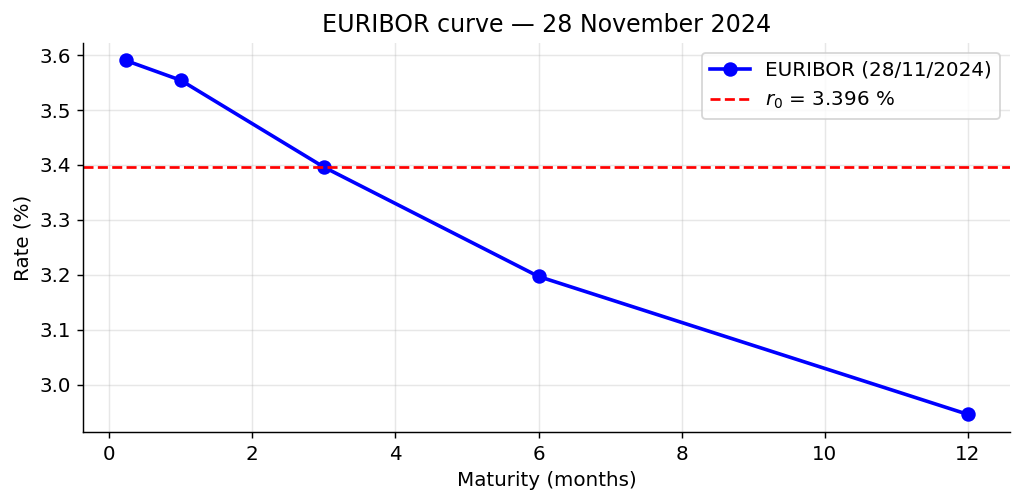

In [2]:

euribor_maturities = np.array([1/52, 1/12, 3/12, 6/12, 12/12])  # in years
euribor_rates      = np.array([3.590, 3.554, 3.396, 3.197, 2.946])  # in %

r0 = euribor_rates[2]  # 3-month EURIBOR
print(f"r₀  =  {r0:.3f} %  (3-month EURIBOR, 28/11/2024)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(euribor_maturities * 12, euribor_rates, "bo-", ms=7, lw=2, label="EURIBOR (28/11/2024)")
ax.axhline(r0, color="red", ls="--", lw=1.5, label=f"$r_0$ = {r0:.3f} %")
ax.set_xlabel("Maturity (months)"); ax.set_ylabel("Rate (%)")
ax.set_title("EURIBOR curve — 28 November 2024")
ax.legend(); plt.tight_layout(); plt.show()


### Computing $\mathbb{E}[R_t]$ to estimate $\beta$

#### Analytical solution of the SDE

Set $Y_t = e^{\alpha t}R_t$. By Itô's formula,

$$
dY_t = \alpha\beta e^{\alpha t}\,dt + \sigma e^{\alpha t}\,dB_t.
$$

Integrating from $0$ to $t$ gives

$$
R_t = r_0 e^{-\alpha t}
      + \beta(1-e^{-\alpha t})
      + \sigma e^{-\alpha t}\int_0^t e^{\alpha s}\,dB_s.
$$

Taking expectations removes the stochastic integral, so

$$
\mathbb{E}[R_t] = r_0 e^{-\alpha t} + \beta(1-e^{-\alpha t}).
$$

For the long-term mean $\beta$, we use a euro area long-term reference level inspired by EIOPA assumptions. In this notebook, we set $\beta = 2.50\%$.


β  =  2.50 %  (EIOPA euro area UFR, November 2024)


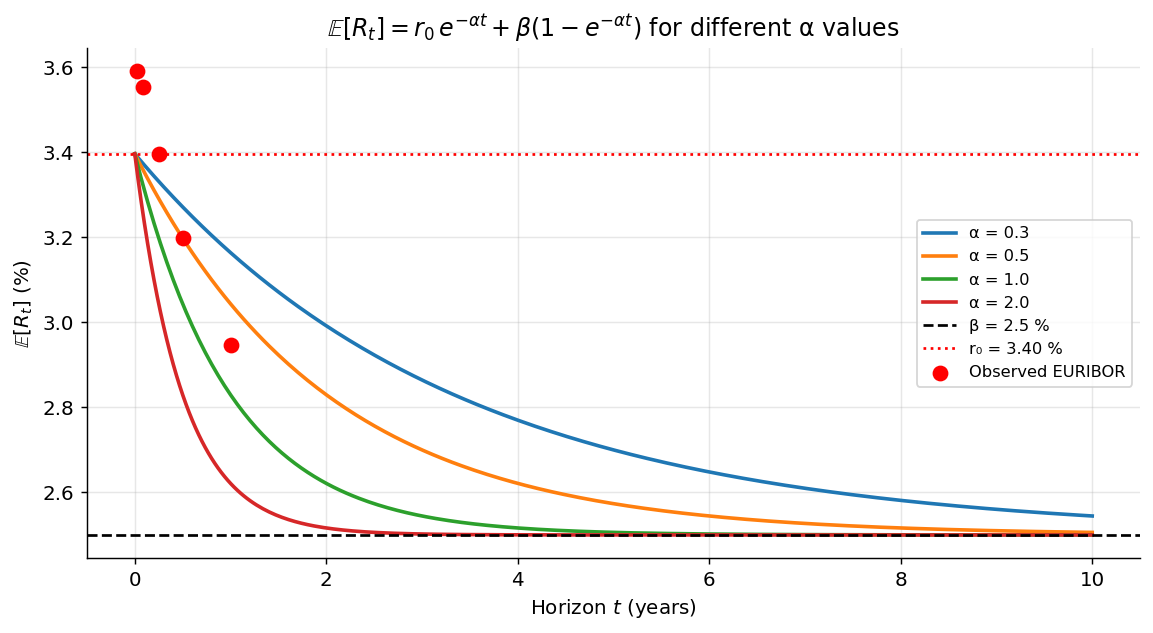

In [3]:
beta = 2.50  # % — long-term equilibrium rate (EIOPA UFR / RFR long term)
print(f"β  =  {beta:.2f} %  (EIOPA euro area UFR, November 2024)")

# Visualization: E[Rt] for different values of α
t_plot = np.linspace(0, 10, 300)
alpha_preview = [0.3, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(9, 5))
for a in alpha_preview:
    E_Rt = r0 * np.exp(-a * t_plot) + beta * (1 - np.exp(-a * t_plot))
    ax.plot(t_plot, E_Rt, lw=2, label=f"α = {a}")

ax.axhline(beta, color="black", ls="--", lw=1.5, label=f"β = {beta} %")
ax.axhline(r0,   color="red",   ls=":",  lw=1.5, label=f"r₀ = {r0:.2f} %")
ax.scatter(euribor_maturities, euribor_rates, zorder=5, color="red",
           s=60, label="Observed EURIBOR")

ax.set_xlabel("Horizon $t$ (years)")
ax.set_ylabel("$\\mathbb{E}[R_t]$ (%)")
ax.set_title(r"$\mathbb{E}[R_t] = r_0\,e^{-\alpha t} + \beta(1-e^{-\alpha t})$"
             " for different α values")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


### Estimating $\alpha$

We observe the EURIBOR curve $(t_i, r_i^{\text{obs}})$ and interpret each observed rate as an approximation of the expected short rate at the corresponding maturity:

$$
r_i^{\text{obs}} \approx \mathbb{E}[R_{t_i}].
$$

The speed of mean reversion $\alpha$ is estimated by least squares:

$$
\hat{\alpha}
=
\arg\min_{\alpha>0}
\sum_i
\left(
\mathbb{E}[R_{t_i};\alpha] - r_i^{\text{obs}}
\right)^2.
$$

Here,

$$
\mathbb{E}[R_{t_i};\alpha]
=
r_0 e^{-\alpha t_i}
+
\beta(1-e^{-\alpha t_i}).
$$


α  =  0.5306 year⁻¹  (half-life ≈ 1.31 years)


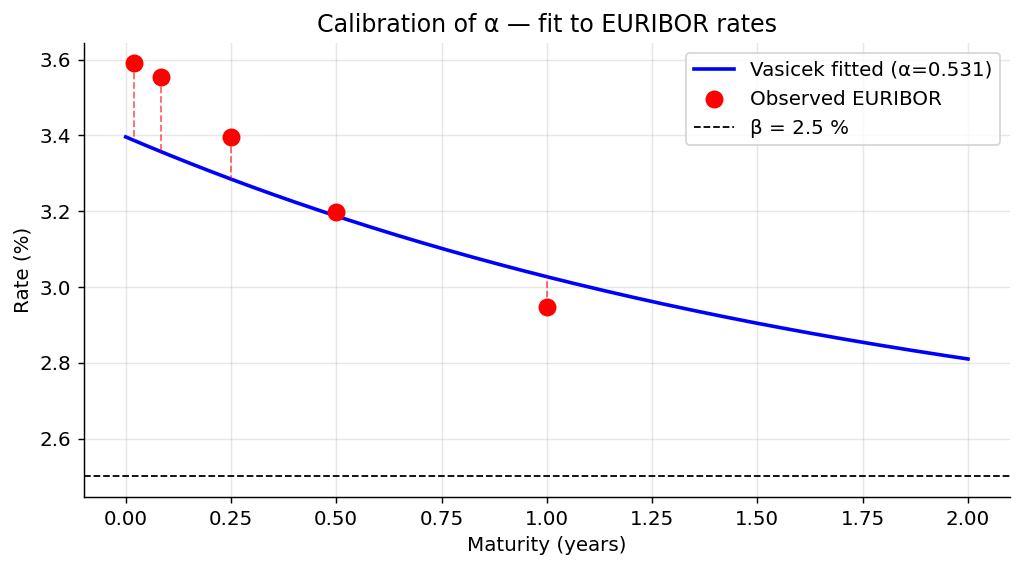


RMSE  =  0.1407 pp


In [4]:
def E_Rt(alpha, t, r0=r0, beta=beta):
    return r0 * np.exp(-alpha * t) + beta * (1 - np.exp(-alpha * t))

def loss(alpha):
    return np.sum((E_Rt(alpha, euribor_maturities) - euribor_rates) ** 2)

res = minimize(loss, x0=0.5, method="L-BFGS-B", bounds=[(1e-4, 20.0)])
alpha = res.x[0]
print(f"α  =  {alpha:.4f} year⁻¹  (half-life ≈ {np.log(2)/alpha:.2f} years)")

# Fitted curve
t_fit = np.linspace(0, 2, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_fit, E_Rt(alpha, t_fit), "b-", lw=2, label=f"Vasicek fitted (α={alpha:.3f})")
ax.scatter(euribor_maturities, euribor_rates, zorder=5, color="red",
           s=80, label="Observed EURIBOR")
for t_i, r_i in zip(euribor_maturities, euribor_rates):
    ax.plot([t_i, t_i], [r_i, E_Rt(alpha, t_i)],
            "r--", lw=1, alpha=0.6)
ax.axhline(beta, color="k", ls="--", lw=1, label=f"β = {beta} %")
ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Rate (%)")
ax.set_title("Calibration of α — fit to EURIBOR rates")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nRMSE  =  {np.sqrt(res.fun / len(euribor_rates)):.4f} pp")


### Computing $\operatorname{Var}(R_t)$ to estimate $\sigma$

From the strong solution,

$$
R_t - \mathbb{E}[R_t]
=
\sigma e^{-\alpha t}\int_0^t e^{\alpha s}\,dB_s.
$$

Using Itô's isometry,

$$
\operatorname{Var}(R_t)
=
\frac{\sigma^2}{2\alpha}\left(1-e^{-2\alpha t}\right).
$$

The stationary variance is obtained by letting $t \to +\infty$:

$$
\operatorname{Var}_{\infty}(R)
=
\frac{\sigma^2}{2\alpha}.
$$

In this project, $\sigma$ is set from an annualized volatility assumption of 75 basis points.


σ    =  0.7500 pp/√year  (75 bps)
σ_∞  =  0.7280 pp  (stationary standard deviation)


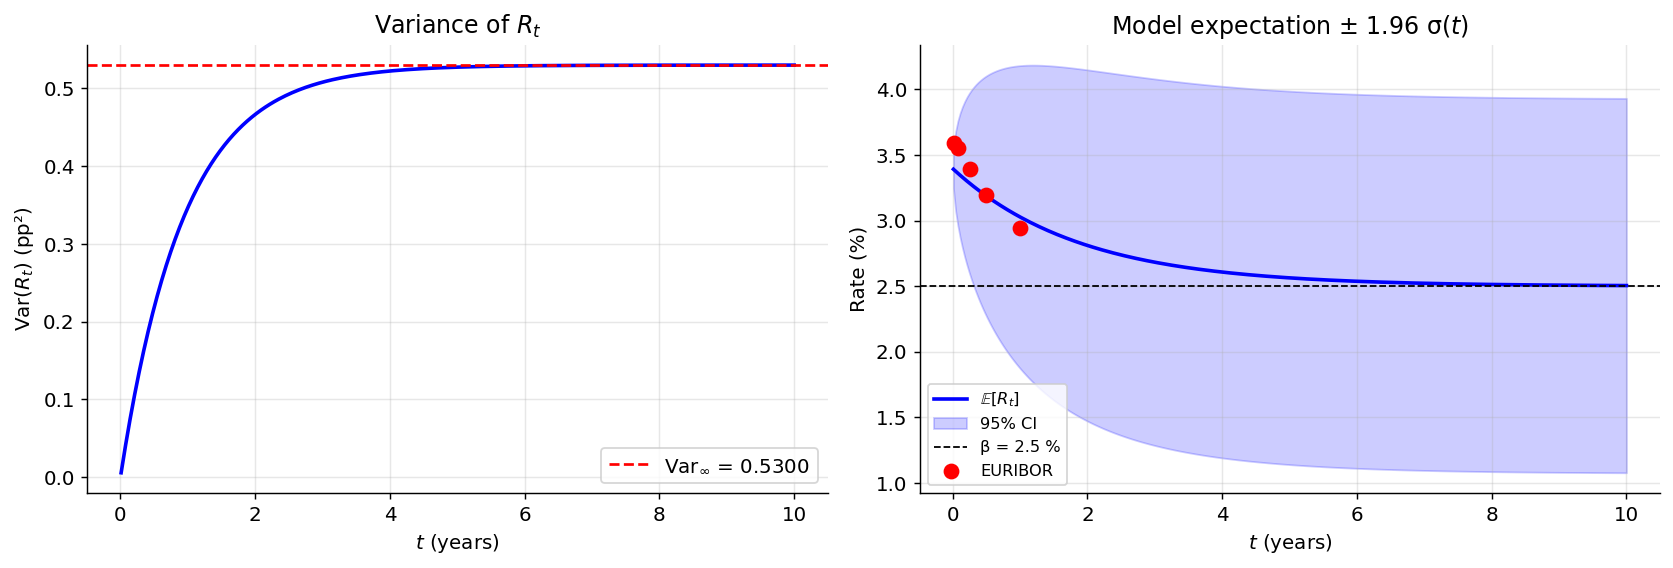

In [5]:

sigma_annualized_bps = 75          # bps
sigma = sigma_annualized_bps / 100 # in percentage points

# Consistency check: stationary variance
var_inf = sigma**2 / (2 * alpha)
print(f"σ    =  {sigma:.4f} pp/√year  ({sigma_annualized_bps} bps)")
print(f"σ_∞  =  {np.sqrt(var_inf):.4f} pp  (stationary standard deviation)")

# Standard deviation as a function of time
t_v = np.linspace(0.01, 10, 300)
std_Rt = np.sqrt(sigma**2 / (2*alpha) * (1 - np.exp(-2*alpha*t_v)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: variance as a function of time
axes[0].plot(t_v, std_Rt**2, "b-", lw=2)
axes[0].axhline(var_inf, color="r", ls="--", lw=1.5,
                label=f"Var$_\\infty$ = {var_inf:.4f}")
axes[0].set_xlabel("$t$ (years)"); axes[0].set_ylabel("Var$(R_t)$ (pp²)")
axes[0].set_title("Variance of $R_t$"); axes[0].legend()

# Right panel: standard deviation and 95% confidence interval
E_R = r0 * np.exp(-alpha*t_v) + beta*(1 - np.exp(-alpha*t_v))
axes[1].plot(t_v, E_R, "b-", lw=2, label="$\\mathbb{E}[R_t]$")
axes[1].fill_between(t_v, E_R - 1.96*std_Rt, E_R + 1.96*std_Rt,
                     alpha=0.2, color="blue", label="95% CI")
axes[1].axhline(beta, color="k", ls="--", lw=1, label=f"β = {beta} %")
axes[1].scatter(euribor_maturities, euribor_rates, color="red", zorder=5,
                s=60, label="EURIBOR")
axes[1].set_xlabel("$t$ (years)"); axes[1].set_ylabel("Rate (%)")
axes[1].set_title("Model expectation ± 1.96 σ$(t)$")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


### Summary of calibrated parameters

In [6]:
print("=" * 50)
print("CALIBRATED PARAMETERS OF THE VASICEK MODEL")
print("=" * 50)
print(f"  r₀    = {r0:.4f} %")
print(f"  β     = {beta:.4f} %")
print(f"  α     = {alpha:.4f} year⁻¹")
print(f"  σ     = {sigma:.4f} pp/√year")
print(f"  Half-life = {np.log(2)/alpha:.2f} years")
print(f"  stationary σ = {np.sqrt(sigma**2/(2*alpha)):.4f} pp")


CALIBRATED PARAMETERS OF THE VASICEK MODEL
  r₀    = 3.3960 %
  β     = 2.5000 %
  α     = 0.5306 year⁻¹
  σ     = 0.7500 pp/√year
  Half-life = 1.31 years
  stationary σ = 0.7280 pp


## 3 - Simulation: Pure Vasicek Model <a id="3-simulation"></a>

### Approximation scheme

We start from the general Milstein scheme. For an SDE of the form $dX_t = a(X_t)\,dt + b(X_t)\,dB_t$, the Milstein discretization is

$$
X_{n+1}
=
X_n
+
a(X_n)h
+
b(X_n)\Delta W_n
+
\frac12 b(X_n)b'(X_n)(\Delta W_n^2-h),
$$

where $h=T/N$ and $\Delta W_n \sim \mathcal{N}(0,h)$.

#### Application to the Vasicek model

For the Vasicek model,

$$
dR_t = \alpha(\beta-R_t)\,dt + \sigma\,dB_t,
$$

the diffusion coefficient is constant: $b(x)=\sigma$. Therefore $b'(x)=0$, and the Milstein correction term is exactly zero.

The scheme reduces to Euler-Maruyama:

$$
R_{n+1}
=
R_n
+
\alpha(\beta-R_n)h
+
\sigma\Delta W_n.
$$

This is expected for diffusions with additive noise: Milstein and Euler-Maruyama coincide.


In [7]:
def milstein_vasicek(r0, alpha, beta, sigma, T, N, n_paths, seed=42):
  
    rng = np.random.default_rng(seed)
    h       = T / N
    sqrt_h  = np.sqrt(h)
    R       = np.empty((n_paths, N + 1))
    R[:, 0] = r0
    dW = rng.normal(0.0, sqrt_h, (n_paths, N))
    for n in range(N):
       
        R[:, n+1] = R[:, n] + alpha*(beta - R[:, n])*h + sigma*dW[:, n]

    return R

# ── Simulation parameters ─────────────────────────────────────────────────────
N_PATHS = 50_000
N_STEPS = 10    # 10 time steps
T_MAX   = 5.0   # maximum horizon to store all paths
SEED    = 42

print(f"Simulation: {N_PATHS:,} paths, N={N_STEPS} steps, T={T_MAX} years")
R_vasicek = milstein_vasicek(r0, alpha, beta, sigma, T=T_MAX, N=N_STEPS,
                              n_paths=N_PATHS, seed=SEED)
print(f"R_vasicek array : {R_vasicek.shape}  (paths × steps+1)")

t_grid = np.linspace(0, T_MAX, N_STEPS + 1)


Simulation: 50,000 paths, N=10 steps, T=5.0 years
R_vasicek array : (50000, 11)  (paths × steps+1)


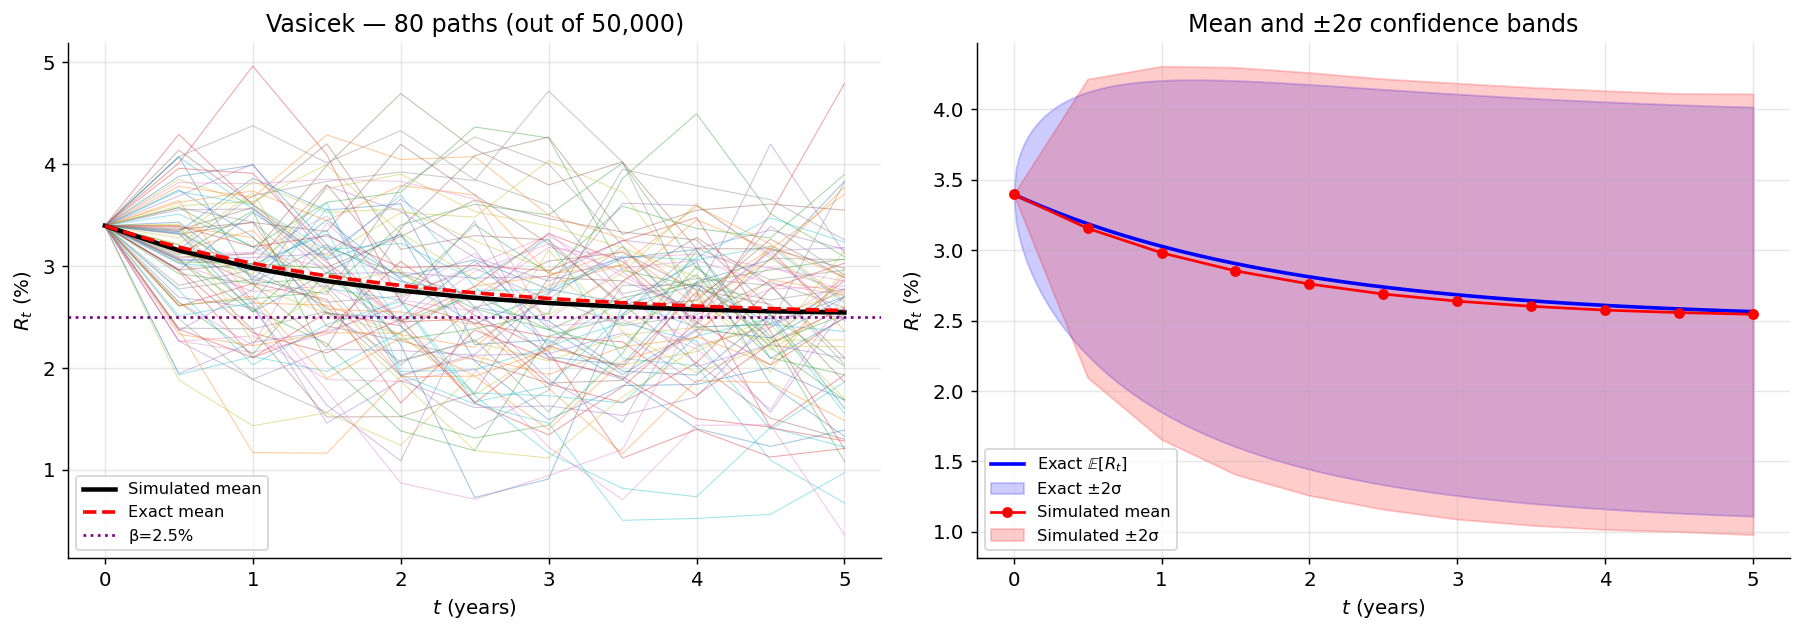

In [8]:
#  Path visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A few sample paths
n_show = 80
for i in range(n_show):
    axes[0].plot(t_grid, R_vasicek[i], lw=0.6, alpha=0.4)

# Simulated vs exact mean
mean_sim = R_vasicek.mean(axis=0)
std_sim  = R_vasicek.std(axis=0)
t_exact  = np.linspace(0, T_MAX, 300)
mean_ex  = r0*np.exp(-alpha*t_exact) + beta*(1 - np.exp(-alpha*t_exact))
std_ex   = np.sqrt(sigma**2/(2*alpha) * (1 - np.exp(-2*alpha*t_exact)))

axes[0].plot(t_grid, mean_sim, "k-",  lw=2.5, label="Simulated mean")
axes[0].plot(t_exact, mean_ex, "r--", lw=2,   label="Exact mean")
axes[0].axhline(beta, color="purple", ls=":", lw=1.5, label=f"β={beta}%")
axes[0].set_xlabel("$t$ (years)"); axes[0].set_ylabel("$R_t$ (%)")
axes[0].set_title(f"Vasicek — {n_show} paths (out of {N_PATHS:,})")
axes[0].legend(fontsize=9)

# Mean and ±2σ
axes[1].plot(t_exact, mean_ex, "b-",  lw=2, label="Exact $\\mathbb{E}[R_t]$")
axes[1].fill_between(t_exact,
                     mean_ex - 2*std_ex,
                     mean_ex + 2*std_ex,
                     alpha=0.2, color="blue", label="Exact ±2σ")
axes[1].plot(t_grid, mean_sim, "ro-", ms=5, lw=1.5, label="Simulated mean")
axes[1].fill_between(t_grid,
                     mean_sim - 2*std_sim,
                     mean_sim + 2*std_sim,
                     alpha=0.2, color="red", label="Simulated ±2σ")
axes[1].set_xlabel("$t$ (years)"); axes[1].set_ylabel("$R_t$ (%)")
axes[1].set_title("Mean and ±2σ confidence bands")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


In [9]:
#  Indices of the selected time steps 
# N=10 steps over T=5 years → h = 0.5 year
# t=0.5 → step 1, t=1 → step 2, t=2 → step 4, t=5 → step 10
idx_06m = 1   # t = 0.5 year
idx_01y = 2   # t = 1.0 year
idx_02y = 4   # t = 2.0 years
idx_05y = 10  # t = 5.0 years

print(f"Time step : h = {T_MAX/N_STEPS:.2f} year")
print(f"  t=0.5 → step {idx_06m}, t=1.0 → step {idx_01y}, "
      f"t=2.0 → step {idx_02y}, t=5.0 → step {idx_05y}")

def stats_at(R, idx, label, t):
    rates = R[:, idx]
    m, s = rates.mean(), rates.std()
    ci95 = 1.96 * s / np.sqrt(len(rates))
    m_ex = r0*np.exp(-alpha*t) + beta*(1 - np.exp(-alpha*t))
    s_ex = np.sqrt(sigma**2/(2*alpha)*(1 - np.exp(-2*alpha*t)))
    print(f"\n── {label} (t = {t} year) ──")
    print(f"  Simulated mean  : {m:.4f} %  [IC95: ±{ci95:.4f}]")
    print(f"  Exact mean   : {m_ex:.4f} %")
    print(f"  Standard deviation sim.  : {s:.4f} %")
    print(f"  Standard deviation exact : {s_ex:.4f} %")
    return rates

print("=" * 55)
print("RESULTS — PURE VASICEK MODEL (Milstein, N=10 steps, 50,000 paths)")
print("=" * 55)

R_06m = stats_at(R_vasicek, idx_06m, "6-month rate", 0.5)
R_01y = stats_at(R_vasicek, idx_01y, "1-year rate",   1.0)
R_05y = stats_at(R_vasicek, idx_05y, "5-year rate",  5.0)
R_02y = R_vasicek[:, idx_02y]




# Probability P(R_2 > 4%)

print("=" * 55)
print("Computing the probability P(R_2 > 4%)")
print("=" * 55)

p_2y_gt4 = (R_02y > 4.0).mean()
p_2y_ex  = 1 - sps.norm.cdf(
    4.0,
    loc  = r0*np.exp(-alpha*2) + beta*(1-np.exp(-alpha*2)),
    scale= np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-4*alpha)))
)
print(f"\n── P(R_2 > 4%) ──")
print(f"  Monte Carlo : {p_2y_gt4:.4f}  ({p_2y_gt4*100:.2f} %)")
print(f"  Exact       : {p_2y_ex:.4f}  ({p_2y_ex*100:.2f} %)")


Time step : h = 0.50 year
  t=0.5 → step 1, t=1.0 → step 2, t=2.0 → step 4, t=5.0 → step 10
RESULTS — PURE VASICEK MODEL (Milstein, N=10 steps, 50,000 paths)

── 6-month rate (t = 0.5 year) ──
  Simulated mean  : 3.1547 %  [IC95: ±0.0046]
  Exact mean   : 3.1872 %
  Standard deviation sim.  : 0.5298 %
  Standard deviation exact : 0.4672 %

── 1-year rate (t = 1.0 year) ──
  Simulated mean  : 2.9806 %  [IC95: ±0.0058]
  Exact mean   : 3.0271 %
  Standard deviation sim.  : 0.6626 %
  Standard deviation exact : 0.5888 %

── 5-year rate (t = 5.0 year) ──
  Simulated mean  : 2.5445 %  [IC95: ±0.0069]
  Exact mean   : 2.5631 %
  Standard deviation sim.  : 0.7825 %
  Standard deviation exact : 0.7262 %
Computing the probability P(R_2 > 4%)

── P(R_2 > 4%) ──
  Monte Carlo : 0.0499  (4.99 %)
  Exact       : 0.0407  (4.07 %)


EURIBOR vs. SIMULATION COMPARISON
  Observed 6M EURIBOR  : 3.197 %
  Vasicek E[R_0.5] : 3.155 %  (difference : -0.042 pp)

  Observed 12M EURIBOR : 2.946 %
  Vasicek E[R_1]   : 2.981 %  (difference : +0.035 pp)

  Comment: the Vasicek model is a one-factor model with
  mean reversion. It cannot exactly reproduce an arbitrary
  yield curve, but it captures the mean-reverting dynamics well.


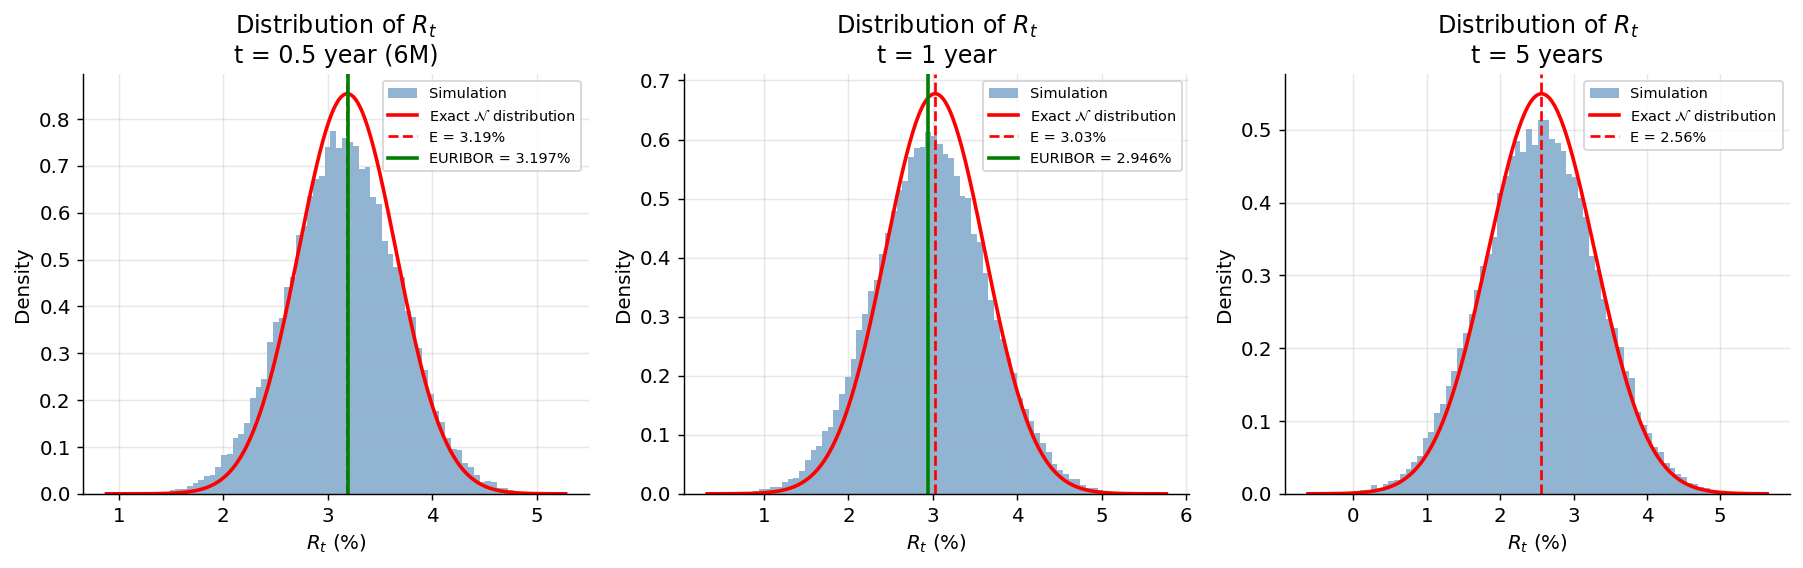

In [10]:
#  Comparison with EURIBOR rates 
print("=" * 55)
print("EURIBOR vs. SIMULATION COMPARISON")
print("=" * 55)
euribor_6m = euribor_rates[3]   # EURIBOR 6 months
euribor_1y = euribor_rates[4]   # 12-month EURIBOR

mean_06m = R_06m.mean()
mean_01y = R_01y.mean()

print(f"  Observed 6M EURIBOR  : {euribor_6m:.3f} %")
print(f"  Vasicek E[R_0.5] : {mean_06m:.3f} %  (difference : {mean_06m-euribor_6m:+.3f} pp)")
print()
print(f"  Observed 12M EURIBOR : {euribor_1y:.3f} %")
print(f"  Vasicek E[R_1]   : {mean_01y:.3f} %  (difference : {mean_01y-euribor_1y:+.3f} pp)")
print()
print("  Comment: the Vasicek model is a one-factor model with")
print("  mean reversion. It cannot exactly reproduce an arbitrary")
print("  yield curve, but it captures the mean-reverting dynamics well.")

#  Histograms at different maturities 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

data_list  = [R_06m,  R_01y,          R_05y]
labels     = ["t = 0.5 year (6M)", "t = 1 year", "t = 5 years"]
t_vals     = [0.5, 1.0, 5.0]
euribor_ref= [euribor_6m, euribor_1y, None]

for ax, rates, lbl, tv, eref in zip(axes, data_list, labels, t_vals, euribor_ref):
    m_ex = r0*np.exp(-alpha*tv) + beta*(1-np.exp(-alpha*tv))
    s_ex = np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-2*alpha*tv)))
    x_range = np.linspace(rates.min(), rates.max(), 300)

    ax.hist(rates, bins=80, density=True, color="steelblue", alpha=0.6,
            label="Simulation")
    ax.plot(x_range, sps.norm.pdf(x_range, m_ex, s_ex),
            "r-", lw=2, label="Exact $\\mathcal{N}$ distribution")
    ax.axvline(m_ex, color="red",    ls="--", lw=1.5, label=f"E = {m_ex:.2f}%")
    if eref:
        ax.axvline(eref, color="green", ls="-",  lw=2,   label=f"EURIBOR = {eref:.3f}%")

    ax.set_xlabel("$R_t$ (%)"); ax.set_ylabel("Density")
    ax.set_title(f"Distribution of $R_t$\n{lbl}")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


## 4 - Simulation: Vasicek Model with Jumps <a id="4-jumps"></a>

### Extended model: Euler scheme with a compound Poisson process

We now enrich the Vasicek model by adding jumps:

$$
dR_t
=
\alpha(\beta - R_t)\,dt
+
\sigma\,dB_t
+
dJ_t,
\qquad R_0=r_0.
$$

The jump process is defined by

$$
J_t = \sum_{i=1}^{N_t} X_i,
$$

where $(N_t)_{t\geq0}$ is a Poisson process with intensity $\lambda$, and the jump sizes $X_i$ follow a double-exponential distribution, also known as the Kou distribution:

$$
f_X(x)
=
p\eta_1 e^{-\eta_1 x}\mathbf{1}_{x>0}
+
(1-p)\eta_2 e^{\eta_2 x}\mathbf{1}_{x<0}.
$$

The parameters used here are $p=0.4$, $\eta_1=0.05$, $\eta_2=0.1$, and $\lambda=1$ jump per year. These values are chosen for illustration.

The expected jump size is

$$
\mathbb{E}[X]
=
\frac{p}{\eta_1}
-
\frac{1-p}{\eta_2}
=
2 \text{ percentage points}.
$$

To simulate a jump size:

- draw $U \sim \mathcal{U}([0,1])$;
- if $U < p$, generate a positive exponential jump;
- otherwise, generate a negative exponential jump.

#### Euler scheme with exact jump times

We simulate the exact jump times of the Poisson process.  
For each path, we draw $N_T \sim \mathcal{P}(\lambda T)$ jump times and sort them over $[0,T]$.

Between two consecutive times, the rate follows the Euler discretization of the continuous Vasicek part.  
At a jump time $\tau_j$, the rate is updated by adding the jump size:

$$
R_{\tau_j} \leftarrow R_{\tau_j^-} + X_j.
$$


Intensity   λ    = 1.0  jump/year
E[X]             = 2.00 pp  (average jump)
Expected jumps over 5Y = 5.0



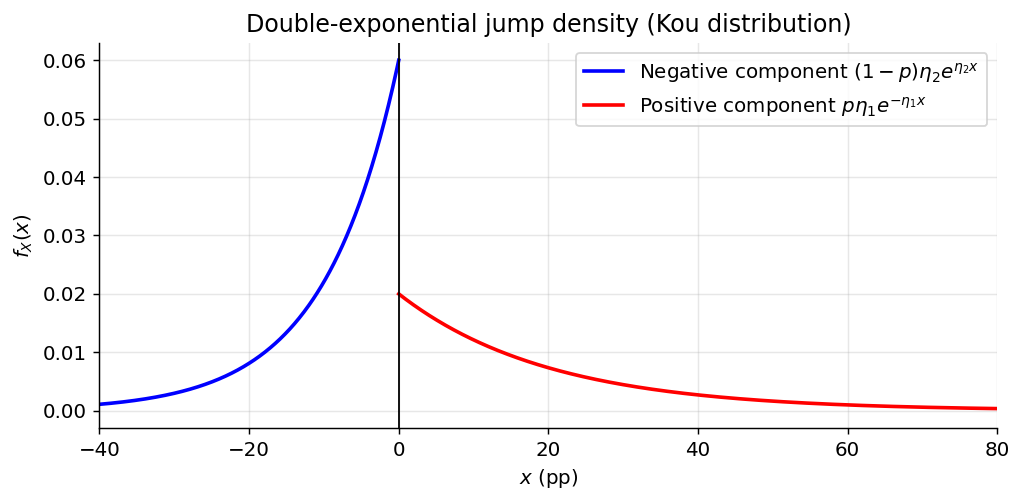

In [11]:
lam  = 1.0   # Poisson intensity (jumps per year) — illustrative choice
p    = 0.4   # probability of a positive jump
eta1 = 0.05  # Exp+ parameter (in pp⁻¹)
eta2 = 0.10  # Exp- parameter (in pp⁻¹)

mean_jump = p/eta1 - (1-p)/eta2
print(f"Intensity   λ    = {lam}  jump/year")
print(f"E[X]             = {mean_jump:.2f} pp  (average jump)")
print(f"Expected jumps over 5Y = {lam*5:.1f}")
print()

#  Density check 
x_pos = np.linspace(0.001, 80, 1000)
x_neg = np.linspace(-80, -0.001, 1000)
fx_pos = p   * eta1 * np.exp(-eta1 * x_pos)
fx_neg = (1-p)* eta2 * np.exp( eta2 * x_neg)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_neg, fx_neg, "b-",  lw=2, label=f"Negative component $(1-p)\\eta_2 e^{{\\eta_2 x}}$")
ax.plot(x_pos, fx_pos, "r-",  lw=2, label=f"Positive component $p\\eta_1 e^{{-\\eta_1 x}}$")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("$x$ (pp)"); ax.set_ylabel("$f_X(x)$")
ax.set_title("Double-exponential jump density (Kou distribution)")
ax.legend(); ax.set_xlim(-40, 80); plt.tight_layout(); plt.show()


In [12]:
#  Euler simulation with exact jump times (vectorized) 
def euler_vasicek_jumps(r0, alpha, beta, sigma,
                         lam, p, eta1, eta2,
                         T, N, n_paths, seed=42):
 
    rng  = np.random.default_rng(seed)
    h    = T / N
    t_grid = np.linspace(0, T, N + 1)

    #  Pre-generate jumps for all paths 
    # Upper bound: 0.9999 quantile of a Poisson(λT)
    from scipy.stats import poisson as _poi
    max_jumps = max(1, int(_poi.ppf(0.9999, lam * T)) + 5)

    n_actual  = rng.poisson(lam * T, n_paths)          # (n_paths,)

    # Jump times: uniform on [0,T], sorted for each path
    raw_times = rng.uniform(0, T, (n_paths, max_jumps))
    raw_times = np.sort(raw_times, axis=1)

    # Mask: remove jumps beyond n_actual[i]
    idx_mask  = np.arange(max_jumps)[np.newaxis, :]    # (1, max_jumps)
    raw_times[idx_mask >= n_actual[:, np.newaxis]] = np.inf

    # Jump sizes: double-exponential distribution
    u_jump  = rng.random((n_paths, max_jumps))
    sizes   = np.where(
        u_jump < p,
        rng.exponential(1.0/eta1, (n_paths, max_jumps)),
       -rng.exponential(1.0/eta2, (n_paths, max_jumps))
    )

    #  Step-by-step integration 
    R       = np.full(n_paths, float(r0))
    t_curr  = np.zeros(n_paths)               # current time in each path

    for n in range(N):
        t_start = t_grid[n]
        t_end   = t_grid[n + 1]
        t_curr[:] = t_start

        # Process all jump slots falling in (t_start, t_end]
        for j in range(max_jumps):
            tau    = raw_times[:, j]           # (n_paths,)
            active = (tau > t_curr) & (tau <= t_end)
            if not active.any():
                continue
            # Euler step from the current time to τ
            dt = np.where(active, tau - t_curr, 0.0)
            dW = rng.normal(0.0, np.sqrt(np.maximum(dt, 0.0)), n_paths)
            R  += np.where(active, alpha*(beta - R)*dt + sigma*dW, 0.0)
            # Apply the jump
            R  += np.where(active, sizes[:, j], 0.0)
            t_curr = np.where(active, tau, t_curr)

        # Final Euler step: t_curr → t_end
        dt = t_end - t_curr
        dW = rng.normal(0.0, np.sqrt(np.maximum(dt, 1e-15)), n_paths)
        R += alpha*(beta - R)*dt + sigma*dW

    return R

#  Simulate over the selected horizons 
print("Simulation of Vasicek + jumps (50,000 paths)…", end=" ")

horizons = {"6M": 0.5, "1Y": 1.0, "2Y": 2.0, "5Y": 5.0}
R_jump = {}
for lbl, T_h in horizons.items():
    N_h = max(10, int(10 * T_h))   # ≥ 10 steps, proportional to T
    R_jump[lbl] = euler_vasicek_jumps(
        r0, alpha, beta, sigma,
        lam, p, eta1, eta2,
        T=T_h, N=N_h, n_paths=N_PATHS, seed=SEED
    )



Simulation of Vasicek + jumps (50,000 paths)… 

In [13]:
#  Jump model results 
print("=" * 55)
print("RESULTS — VASICEK + JUMPS (exact Euler, 50,000 paths)")
print("=" * 55)

for lbl, T_h in horizons.items():
    rates = R_jump[lbl]
    m, s  = rates.mean(), rates.std()
    ci95  = 1.96 * s / np.sqrt(N_PATHS)
    print(f"\n  Rate {lbl} (T={T_h} year) :")
    print(f"    Mean  = {m:.4f} %  [IC95: ±{ci95:.4f}]")
    print(f"    Standard deviation = {s:.4f} %")

p_2y_jump = (R_jump["2Y"] > 4.0).mean()
print(f"\n  P(R_2 > 4%) with jumps : {p_2y_jump:.4f}  ({p_2y_jump*100:.2f} %)")
print(f"  P(R_2 > 4%) without jumps : {p_2y_gt4:.4f}  ({p_2y_gt4*100:.2f} %)")


RESULTS — VASICEK + JUMPS (exact Euler, 50,000 paths)

  Rate 6M (T=0.5 year) :
    Mean  = 3.9328 %  [IC95: ±0.1032]
    Standard deviation = 11.7752 %

  Rate 1Y (T=1.0 year) :
    Mean  = 4.3153 %  [IC95: ±0.1153]
    Standard deviation = 13.1506 %

  Rate 2Y (T=2.0 year) :
    Mean  = 4.4420 %  [IC95: ±0.1036]
    Standard deviation = 11.8242 %

  Rate 5Y (T=5.0 year) :
    Mean  = 3.6474 %  [IC95: ±0.0505]
    Standard deviation = 5.7593 %

  P(R_2 > 4%) with jumps : 0.3758  (37.58 %)
  P(R_2 > 4%) without jumps : 0.0499  (4.99 %)


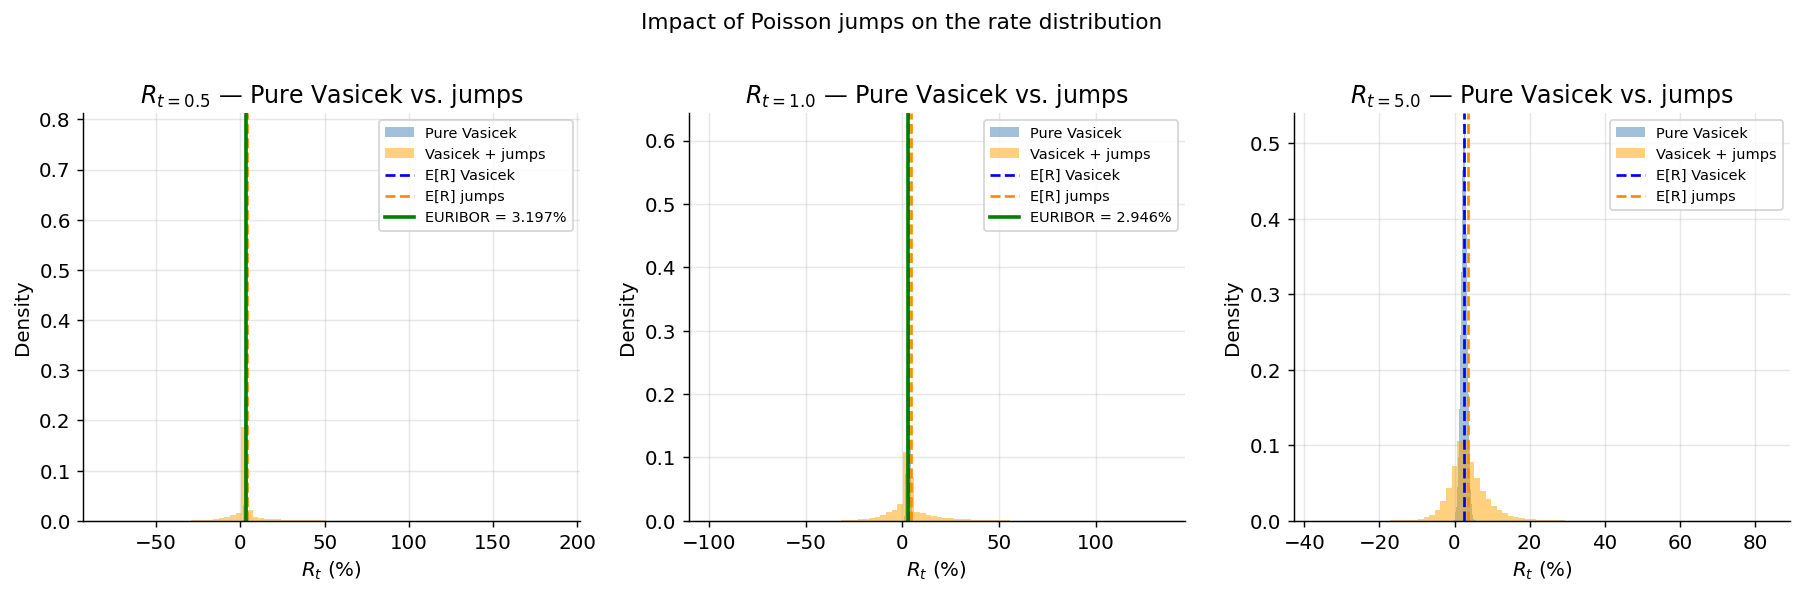

In [14]:
#  Jump visualization 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

horizon_list = [("6M", 0.5, euribor_rates[3]),
                ("1Y", 1.0, euribor_rates[4]),
                ("5Y", 5.0, None)]

for ax, (lbl, T_h, eref) in zip(axes, horizon_list):
    rates_j  = R_jump[lbl]
    rates_v  = R_vasicek[:, int(T_h / (T_MAX/N_STEPS))]  # Pure Vasicek
    m_ex     = r0*np.exp(-alpha*T_h) + beta*(1-np.exp(-alpha*T_h))

    ax.hist(rates_v, bins=80, density=True, color="steelblue",
            alpha=0.5, label="Pure Vasicek")
    ax.hist(rates_j, bins=80, density=True, color="orange",
            alpha=0.5, label="Vasicek + jumps")
    ax.axvline(m_ex, color="blue",  ls="--", lw=1.5, label=f"E[R] Vasicek")
    ax.axvline(rates_j.mean(), color="darkorange", ls="--", lw=1.5,
               label=f"E[R] jumps")
    if eref:
        ax.axvline(eref, color="green", ls="-", lw=2,
                   label=f"EURIBOR = {eref:.3f}%")

    ax.set_xlabel("$R_t$ (%)"); ax.set_ylabel("Density")
    ax.set_title(f"$R_{{t={T_h}}}$ — Pure Vasicek vs. jumps")
    ax.legend(fontsize=8)

plt.suptitle("Impact of Poisson jumps on the rate distribution",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 5 - Comparative Analysis and Conclusions <a id="5-analysis"></a>

This section compares the pure Vasicek model with the jump-extended version.  
The goal is to understand how jumps affect the distribution of future interest rates and the probability of extreme outcomes.


In [19]:
#  Summary table 
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    print("╔════════════════════════════════════════════════════════════════╗")
    print("║          SUMMARY — RATE ESTIMATES (in %)                       ║")
    print("╠══════════════╦══════════════╦═══════════════╦══════════════════╣")
    print("║ Maturity     ║ Obs EURIBOR  ║ Pure Vasicek  ║ Vasicek + jumps  ║")
    print("╠══════════════╬══════════════╬═══════════════╬══════════════════╣")

    rows = [
        ("6 months",  euribor_rates[3],
         R_vasicek[:, idx_06m].mean(), R_jump["6M"].mean()),
        ("1 year",    euribor_rates[4],
         R_vasicek[:, idx_01y].mean(), R_jump["1Y"].mean()),
        ("5 years",   None,
         R_vasicek[:, idx_05y].mean(), R_jump["5Y"].mean()),
    ]
    for label, obs, v, vj in rows:
        obs_str = f"{obs:.3f}" if obs else "  —   "
        print(f"║ {label:<12} ║   {obs_str:<9}  ║   {v:>6.3f}      ║   {vj:>6.3f}         ║")

    print("╠══════════════╩══════════════╩═══════════════╩══════════════════╣")
    print(f"║ P(R₂ > 4%)   ║     —        ║   {p_2y_gt4*100:.2f} %      ║   {p_2y_jump*100:.2f} %        ║")
    print("╚════════════════════════════════════════════════════════════════╝")


╔════════════════════════════════════════════════════════════════╗
║          SUMMARY — RATE ESTIMATES (in %)                       ║
╠══════════════╦══════════════╦═══════════════╦══════════════════╣
║ Maturity     ║ Obs EURIBOR  ║ Pure Vasicek  ║ Vasicek + jumps  ║
╠══════════════╬══════════════╬═══════════════╬══════════════════╣
║ 6 months     ║   3.197      ║    3.155      ║    3.933         ║
║ 1 year       ║   2.946      ║    2.981      ║    4.315         ║
║ 5 years      ║     —        ║    2.544      ║    3.647         ║
╠══════════════╩══════════════╩═══════════════╩══════════════════╣
║ P(R₂ > 4%)   ║     —        ║   4.99 %      ║   37.58 %        ║
╚════════════════════════════════════════════════════════════════╝


In [16]:
#  Validation: exact solution vs simulation 
t_check = np.array([0.5, 1.0, 2.0, 5.0])

print("\nValidation Monte Carlo vs. exact solution (Pure Vasicek)\n")
print(f"{'Horizon':>8}  {'MC mean':>9}  {'Exact mean':>11}  {'MC std':>8}  {'Exact std':>10}")
print("-" * 55)
for t in t_check:
    idx = int(np.round(t / (T_MAX / N_STEPS)))
    mc_m  = R_vasicek[:, idx].mean()
    mc_s  = R_vasicek[:, idx].std()
    ex_m  = r0*np.exp(-alpha*t) + beta*(1-np.exp(-alpha*t))
    ex_s  = np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-2*alpha*t)))
    print(f"{t:>7.1f}y  {mc_m:>9.4f}  {ex_m:>11.4f}  {mc_s:>8.4f}  {ex_s:>10.4f}")



Validation Monte Carlo vs. exact solution (Pure Vasicek)

 Horizon    MC mean   Exact mean    MC std   Exact std
-------------------------------------------------------
    0.5y     3.1547       3.1872    0.5298      0.4672
    1.0y     2.9806       3.0271    0.6626      0.5888
    2.0y     2.7593       2.8100    0.7506      0.6831
    5.0y     2.5445       2.5631    0.7825      0.7262


## 6 - Impact of Jumps on the Distribution <a id="6-jump-impact"></a>

The jump component changes the shape of the distribution. In particular, it creates heavier tails than the pure Gaussian Vasicek model.

To visualize this effect, we compare quantiles and tail densities at the 2-year horizon.


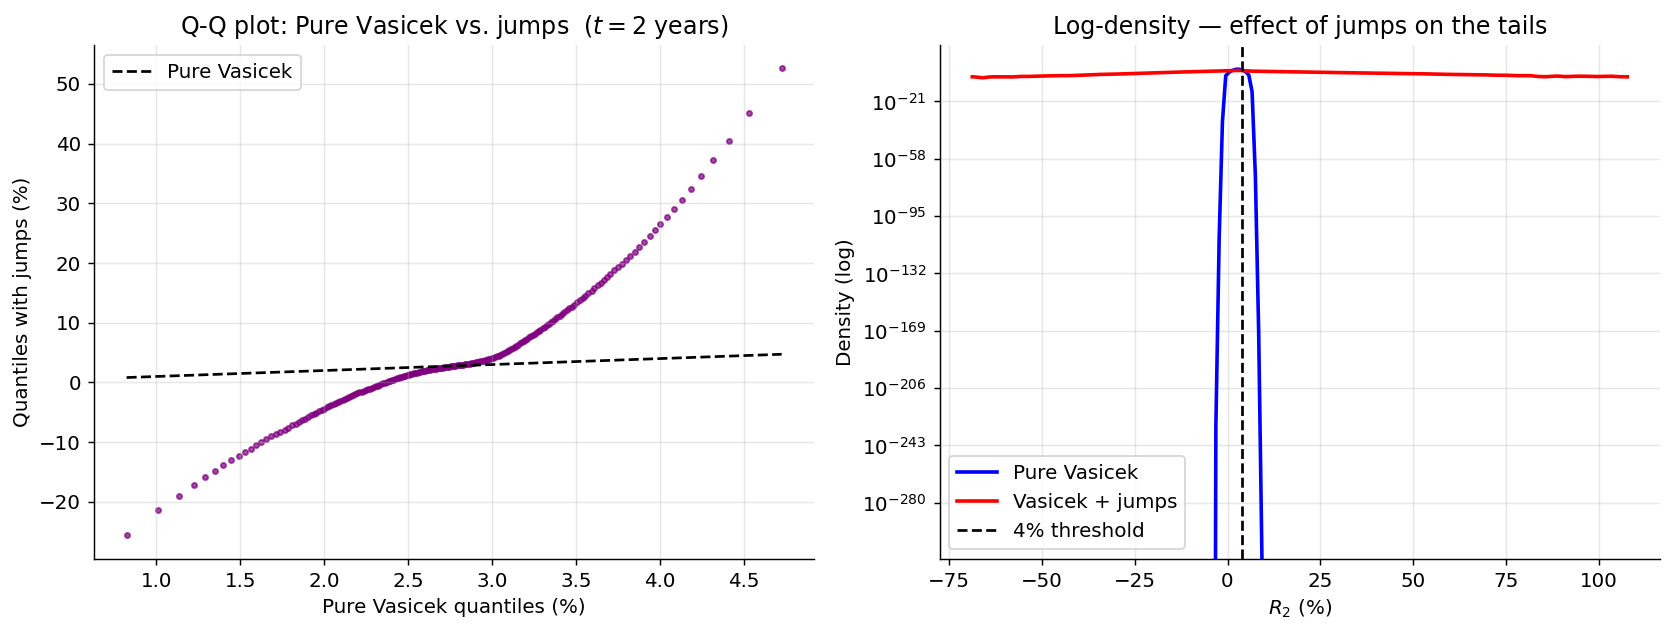


Conclusion: jumps significantly thicken the tails of the
distribution, increasing the probability of extreme rates.


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tail distribution at 2 years
rates_v2  = R_vasicek[:, idx_02y]
rates_j2  = R_jump["2Y"]

# Q-Q plot
quantiles = np.linspace(0.5, 99.5, 200)
q_v = np.percentile(rates_v2, quantiles)
q_j = np.percentile(rates_j2, quantiles)
axes[0].scatter(q_v, q_j, s=8, alpha=0.7, color="purple")
axes[0].plot([q_v.min(), q_v.max()], [q_v.min(), q_v.max()],
             "k--", lw=1.5, label="Pure Vasicek")
axes[0].set_xlabel("Pure Vasicek quantiles (%)"); axes[0].set_ylabel("Quantiles with jumps (%)")
axes[0].set_title("Q-Q plot: Pure Vasicek vs. jumps  ($t=2$ years)")
axes[0].legend()

# Tail distributions (log-scale)
x_range = np.linspace(min(rates_v2.min(), rates_j2.min()),
                       max(rates_v2.max(), rates_j2.max()), 200)
kde_v = sps.gaussian_kde(rates_v2)(x_range)
kde_j = sps.gaussian_kde(rates_j2)(x_range)
axes[1].semilogy(x_range, kde_v, "b-",  lw=2, label="Pure Vasicek")
axes[1].semilogy(x_range, kde_j, "r-",  lw=2, label="Vasicek + jumps")
axes[1].axvline(4.0, color="k", ls="--", lw=1.5, label="4% threshold")
axes[1].set_xlabel("$R_2$ (%)"); axes[1].set_ylabel("Density (log)")
axes[1].set_title("Log-density — effect of jumps on the tails")
axes[1].legend()

plt.tight_layout(); plt.show()

print("\nConclusion: jumps significantly thicken the tails of the")
print("distribution, increasing the probability of extreme rates.")


# Conclusions

**Calibration.**  
The Vasicek model is determined by four parameters: $(r_0, \alpha, \beta, \sigma)$.  
They are obtained from market-based inputs such as EURIBOR rates and a long-term reference level. The estimated mean-reversion speed is consistent with the idea that rates gradually move toward a long-term equilibrium.

**Pure Vasicek simulation.**  
For this model, the Milstein scheme coincides with Euler-Maruyama because the diffusion coefficient is constant. The simulation reproduces the exact Gaussian distribution very well with 50,000 paths and 10 time steps. At longer horizons, the rate progressively converges toward $\beta = 2.50\%$.

**Vasicek model with jumps.**  
Adding a compound Poisson process introduces sudden discontinuities in the rate dynamics. The double-exponential jump distribution creates heavier tails, which is visible in the Q-Q plot and in the log-density plot. As a result, the probability of reaching high rate levels, such as 4% at 2 years, increases.

**Limitations of the Vasicek model.**

- Rates can become negative because the model is Gaussian.
- The model has only one factor, so it cannot perfectly fit an entire yield curve.
- Parameters are assumed to be constant over time.

Natural extensions include the Cox-Ingersoll-Ross model, which keeps rates positive, the Hull-White model, which can fit the initial yield curve exactly, and multi-factor HJM-type models.
